In [3]:
import sys

import os
import glob

import numpy as np

import bagpipes as pipes

import astropy.units as u
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.table import Table, vstack

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

sys.path.append(os.path.abspath('..'))

from mrileyowens.bagpipes import plot

In [119]:

# I'll want to plot:
#   1. Mine and Ryan's catalogs
#   2. My catalog, with those also in Ryan's catalog plotted differently

def plot_mine():

    home = os.getcwd()
    data = f'{home}/data'
    figs = f'{home}/figs'
    results = f'{home}/results'

    files = glob.glob(f'{results}/catalogs/hlsp_jades_jwst_nircam_goods-n_v1.0_goods-s-deep_v2.0_photometry_catalog_f775w_dropouts_*.fits')

    hdul_ryan = fits.open(f'{data}/JADES_f775w_dropouts_Endsley2024.fits')
    coords_ryan = SkyCoord(ra=hdul_ryan[1].data['RA'] * u.deg, dec=hdul_ryan[1].data['DEC'] * u.deg)

    max_sep = 0.1 * u.arcsec

    for file in files:

        hdul = fits.open(file)
        coords = SkyCoord(ra=hdul[1].data['RA'] * u.deg, dec=hdul[1].data['DEC'] * u.deg)

        # Match the matched coordinates to Ryan's catalog, picking out just the galaxy pairs with the correct separation
        idx, d2d, _ = coords_ryan.match_to_catalog_sky(coords)
        idx_matches = idx[d2d < max_sep]
        coords_matches = coords[idx_matches]#idx[d2d < max_sep]]

        coords = np.delete(coords, idx_matches)

        gn_mask = [coords.dec.deg > 0, coords_matches.dec.deg > 0]
        gs_mask = [coords.dec.deg < 0, coords_matches.dec.deg < 0]

        fig_gn, ax_gn = plt.subplots()
        fig_gs, ax_gs = plt.subplots()

        #fig, ax = plt.subplots(1, 2, figsize=(8,4))

        ax_gn.scatter(coords.ra.deg[gn_mask[0]], coords.dec.deg[gn_mask[0]], marker='o', facecolors='none', edgecolors='black', label=f'JADES (N={np.sum(gn_mask[0])})')
        ax_gn.scatter(coords_matches.ra.deg[gn_mask[1]], coords_matches.dec.deg[gn_mask[1]], marker='x', facecolors='green', label=f'JADES + Ryan (N={np.sum(gn_mask[1])})')
        
        ax_gs.scatter(coords.ra.deg[gs_mask[0]], coords.dec.deg[gs_mask[0]], marker='o', facecolors='none', edgecolors='black', label=f'JADES (N={np.sum(gs_mask[0])})')
        ax_gs.scatter(coords_matches.ra.deg[gs_mask[1]], coords_matches.dec.deg[gs_mask[1]], marker='x', facecolors='green', label=f'JADES + Ryan (N={np.sum(gs_mask[1])})')

        '''
        for coord in coords:

            if coord.dec.deg < 0:
                ax_gs.scatter(coord.ra.deg, coord.dec.deg, marker='o', facecolors='none', edgecolors='black', label='JADES')
    
            elif coord.dec.deg > 0:
                ax_gn.scatter(coord.ra.deg, coord.dec.deg, marker='o', facecolors='none', edgecolors='black', label='JADES')

        for coord in coords_matches:

            if coord.dec.deg < 0:
                ax_gs.scatter(coord.ra.deg, coord.dec.deg, marker='x', facecolors='green', label='JADES + Ryan')
    
            elif coord.dec.deg > 0:
                ax_gn.scatter(coord.ra.deg, coord.dec.deg, marker='x', facecolors='green', label='JADES + Ryan')
        '''

        ax_gn.set_xlabel('Right ascension (degrees)')
        ax_gs.set_xlabel('Right ascension (degrees)')

        ax_gn.set_ylabel('Declination (degrees)')
        ax_gs.set_ylabel('Declination (degrees)')

        ax_gn.legend(loc='lower right')
        ax_gs.legend(loc='lower left')

        at = AnchoredText('GOODS-N', loc='upper left', prop=dict(fontweight='bold'))
        ax_gn.add_artist(at)

        at = AnchoredText('GOODS-S', loc='upper right', prop=dict(fontweight='bold'))
        ax_gs.add_artist(at)

        ax_gn.set_aspect('equal', adjustable='box')
        ax_gs.set_aspect('equal', adjustable='box')

        title = 'Before selecting for sufficiently sensitive rest-optical colors' if 'init' in file else 'After selecting for sufficiently sensitive rest-optical colors'

        ax_gn.set_title(title)
        ax_gs.set_title(title)

        ax_gn.xaxis.set_inverted(True)
        ax_gs.xaxis.set_inverted(True)

        #fig_gn.savefig(f'{figs}/hlsp_jades_jwst_nircam_goods-n_v1.0_photometry_catalog_f775w_dropouts_{file.split('_')[-1].split('.')[0]}.pdf', bbox_inches='tight')
        #fig_gs.savefig(f'{figs}/hlsp_jades_jwst_nircam_goods-s-deep_v2.0_photometry_catalog_f775w_dropouts_{file.split('_')[-1].split('.')[0]}.pdf', bbox_inches='tight')

def plot_catalogs():

    '''
    Plot the full catalogs of my own JADES selection and Ryan's
    '''

    home = os.getcwd()
    data = f'{home}/data'
    figs = f'{home}/figs'
    results = f'{home}/results'

    files = glob.glob(f'{results}/catalogs/hlsp_jades_jwst_nircam_goods-n_v1.0_goods-s-deep_v2.0_photometry_catalog_f775w_dropouts_*.fits')

    hdul_ryan = fits.open(f'{data}/JADES_f775w_dropouts_Endsley2024.fits')
    #coords_ryan = SkyCoord(ra=hdul_ryan[1].data['RA'] * u.deg, dec=hdul_ryan[1].data['DEC'] * u.deg)

    # Set the maximum separation to qualify as a match between two catalogs
    max_sep = 0.1 * u.arcsec

    # For each JADES sample selection
    for file in files:

        coords_ryan = SkyCoord(ra=hdul_ryan[1].data['RA'] * u.deg, dec=hdul_ryan[1].data['DEC'] * u.deg)

        # Get the coordinates from the JADES selection
        hdul_jades = fits.open(file)
        coords_jades = SkyCoord(ra=hdul_jades[1].data['RA'] * u.deg, dec=hdul_jades[1].data['DEC'] * u.deg)

        # Match the coordinates of objects in Ryan's catalog to the JADES catalog, selecting just the matches which do not exceed the maximum separation
        idx_jades, d2d_jades, _ = coords_ryan.match_to_catalog_sky(coords_jades)
        idx_jades_matches = idx_jades[d2d_jades < max_sep]

        coords_matches = coords_jades[idx_jades_matches]#idx[d2d < max_sep]]

        #coords_jades = np.delete(coords_jades, idx_jades_matches)

        idx_ryan, d2d_ryan, _ = coords_matches.match_to_catalog_sky(coords_ryan)
        idx_ryan_matches = idx_ryan[d2d_ryan < max_sep]

        coords_jades = np.delete(coords_jades, idx_jades_matches)
        coords_ryan = np.delete(coords_ryan, idx_ryan_matches)
        #coords_jades = np.delete(coords_jades, idx_jades_matches)

        gn_mask = [coords_jades.dec.deg > 0, coords_ryan.dec.deg > 0, coords_matches.dec.deg > 0]
        gs_mask = [coords_jades.dec.deg < 0, coords_ryan.dec.deg < 0, coords_matches.dec.deg < 0]

        fig_gn, ax_gn = plt.subplots()
        fig_gs, ax_gs = plt.subplots()

        ax_gn.scatter(coords_jades.ra.deg[gn_mask[0]], coords_jades.dec.deg[gn_mask[0]], marker='o', facecolors='none', edgecolors='black', label=f'JADES (N={np.sum(gn_mask[0])})')
        ax_gn.scatter(coords_ryan.ra.deg[gn_mask[1]], coords_ryan.dec.deg[gn_mask[1]], marker='s', facecolors='none', edgecolors='red', label=f'Ryan (N={np.sum(gn_mask[1])})')
        ax_gn.scatter(coords_matches.ra.deg[gn_mask[2]], coords_matches.dec.deg[gn_mask[2]], marker='x', facecolors='green', label=f'JADES + Ryan (N={np.sum(gn_mask[2])})')

        ax_gs.scatter(coords_jades.ra.deg[gs_mask[0]], coords_jades.dec.deg[gs_mask[0]], marker='o', facecolors='none', edgecolors='black', label=f'JADES (N={np.sum(gs_mask[0])})')
        ax_gs.scatter(coords_ryan.ra.deg[gs_mask[1]], coords_ryan.dec.deg[gs_mask[1]], marker='s', facecolors='none', edgecolors='red', label=f'Ryan (N={np.sum(gs_mask[1])})')
        ax_gs.scatter(coords_matches.ra.deg[gs_mask[2]], coords_matches.dec.deg[gs_mask[2]], marker='x', facecolors='green', label=f'JADES + Ryan (N={np.sum(gs_mask[2])})')

        #ax_gs.scatter(coords.ra.deg[gs_mask[0]], coords.dec.deg[gs_mask[0]], marker='o', facecolors='none', edgecolors='black', label=f'JADES (N={np.sum(gs_mask[0])})')
        #ax_gs.scatter(coords_matches.ra.deg[gs_mask[1]], coords_matches.dec.deg[gs_mask[1]], marker='x', facecolors='green', label=f'JADES + Ryan (N={np.sum(gs_mask[1])})')

        ax_gn.set_xlabel('Right ascension (degrees)')
        ax_gs.set_xlabel('Right ascension (degrees)')

        ax_gn.set_ylabel('Declination (degrees)')
        ax_gs.set_ylabel('Declination (degrees)')

        ax_gn.legend(loc='lower right')
        ax_gs.legend(loc='lower left')

        at = AnchoredText('GOODS-N', loc='upper left', prop=dict(fontweight='bold'))
        ax_gn.add_artist(at)

        at = AnchoredText('GOODS-S', loc='upper right', prop=dict(fontweight='bold'))
        ax_gs.add_artist(at)

        ax_gn.set_aspect('equal', adjustable='box')
        ax_gs.set_aspect('equal', adjustable='box')

        title = 'Before selecting for sufficiently sensitive rest-optical colors' if 'init' in file else 'After selecting for sufficiently sensitive rest-optical colors'

        ax_gn.set_title(title)
        ax_gs.set_title(title)

        ax_gn.xaxis.set_inverted(True)
        ax_gs.xaxis.set_inverted(True)

        fig_gn.savefig(f'{figs}/hlsp_jades_jwst_nircam_goods-n_v1.0_photometry_catalog_f775w_dropouts_{file.split('_')[-1].split('.')[0]}.pdf', bbox_inches='tight')
        fig_gs.savefig(f'{figs}/hlsp_jades_jwst_nircam_goods-s-deep_v2.0_photometry_catalog_f775w_dropouts_{file.split('_')[-1].split('.')[0]}.pdf', bbox_inches='tight')

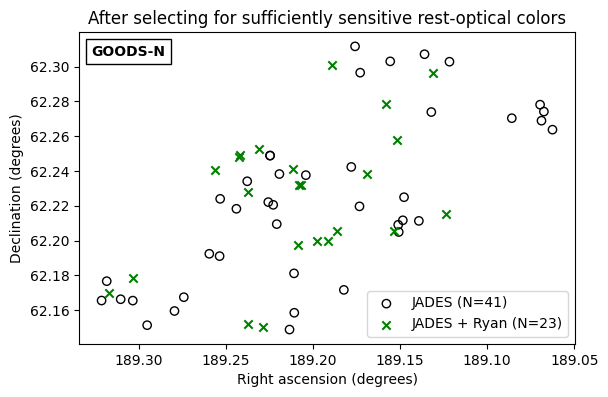

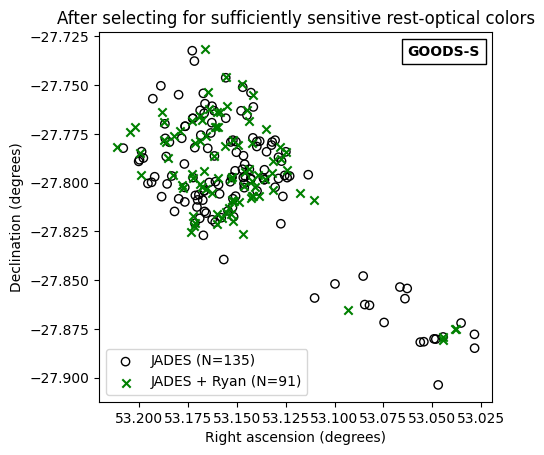

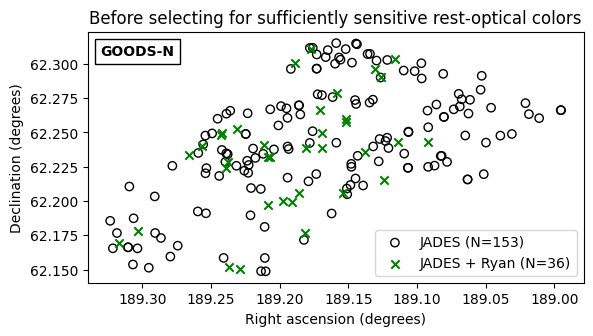

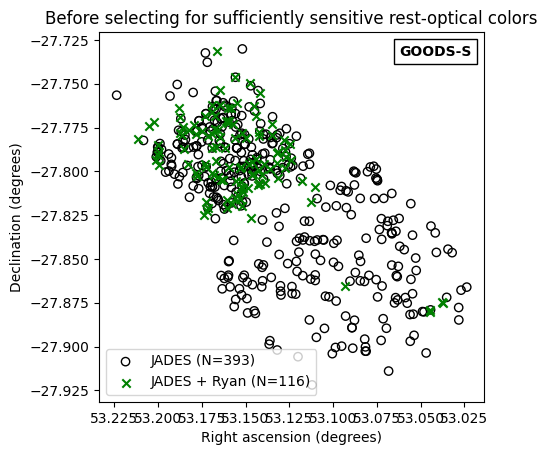

In [114]:
plot_mine()

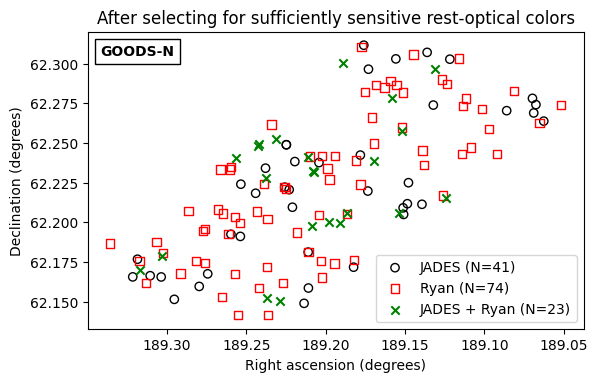

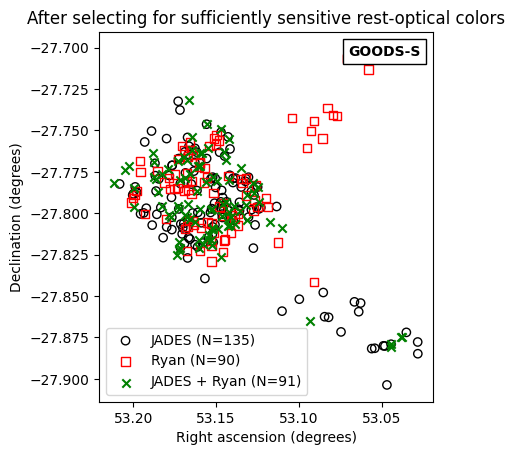

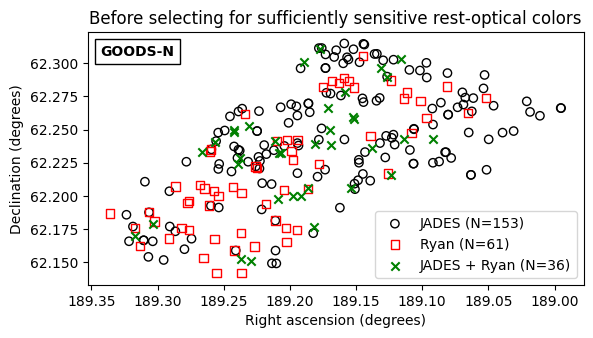

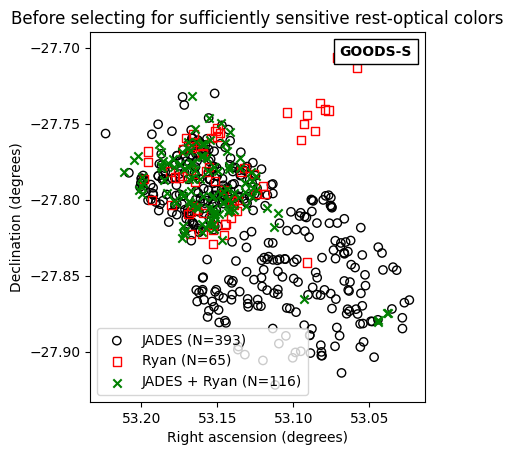

In [120]:
plot_catalogs()